# Customer Segmentation Using Unsupervised Learning
## Professional Portfolio Project

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

## Step 2 — Load Dataset

In [2]:
df = pd.read_csv(r"G:\Data Science\DS 27\Data\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 3 — EDA

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

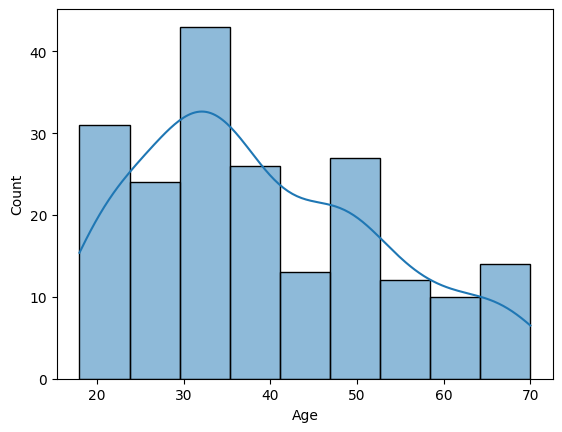

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

sns.histplot(df['Age'], kde=True)
plt.show()

## Step 4 — Preprocessing

In [4]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1})

features=['Age','Annual Income (k$)','Spending Score (1-100)']
X=df[features]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

## Step 5 — Elbow Method

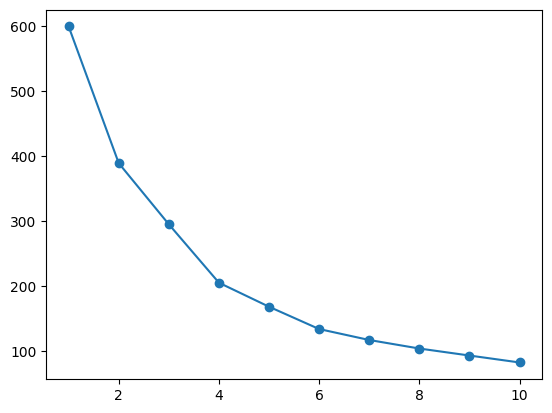

In [5]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.show()

## Step 6 — KMeans

In [6]:
kmeans=KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster']=kmeans.fit_predict(X_scaled)
print("Silhouette Score:",silhouette_score(X_scaled,df['Cluster']))

Silhouette Score: 0.41664341513732767


## Step 7 — PCA Visualization

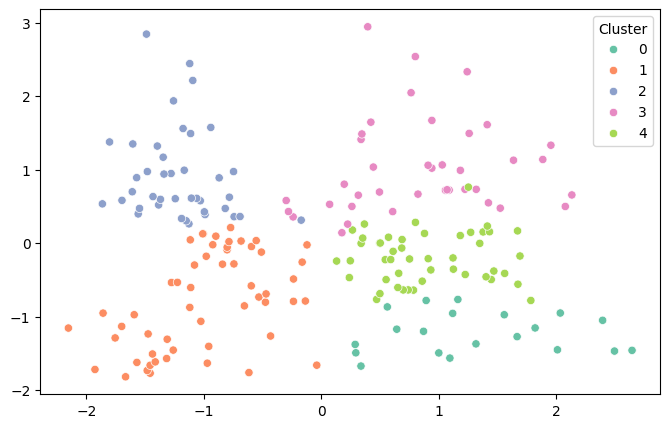

In [7]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=df['Cluster'],palette='Set2')
plt.show()

## Step 8 — t-SNE Visualization

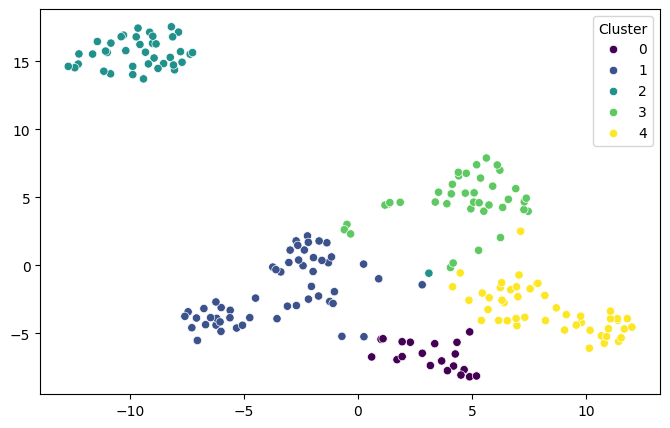

In [8]:
tsne=TSNE(n_components=2,random_state=42)
X_tsne=tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_tsne[:,0],y=X_tsne[:,1],hue=df['Cluster'],palette='viridis')
plt.show()

## Step 9 — Cluster Analysis

In [9]:
df.groupby('Cluster')[features].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## Marketing Strategies

**High Income–High Spending:** Premium campaigns & VIP memberships.

**Low Income–Low Spending:** Discounts and affordability offers.

**High Income–Low Spending:** Personalized engagement and loyalty incentives.

**Young High Spenders:** Social media promotions and trend-focused products.

**Moderate Customers:** Retention strategies and seasonal campaigns.


## Final Conclusion

This project demonstrates:
- Unsupervised Learning (K‑Means)
- Customer Segmentation
- PCA & t‑SNE Dimensionality Reduction
- Business Strategy Development
